In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import tight_layout

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "18_ex_con_2025_full_logit_mean_one"


input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'g_stem_res','gam_stem_x_H','k_xyl_x_H', 'gam_stem_div_g0', 'g_min_loss']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem']

vars_plant_ex = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem', 'gam_stem_x_H','k_xyl_x_H', 'gam_stem_div_g0', 'g_min_loss']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['gam_stem_div_g0'] = df['stem_hydraulic_capacitance']/ df['g0']
df['g_min_loss'] = df['g0'] + df['g_stem_res']

df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)

index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)

df = df[df['RMSE_MAX'] < 1.5]
df_grp = df.groupby(['id'])[vars_all_ex].mean()
dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
#df_norm = (dv - dv.mean()) / dv.std()
df_norm = dv
df_norm['sid'] = df['sid']
df_norm['RMSE_MAX'] = df['RMSE_MAX']
df_norm.shape

/tmp/ipykernel_1482249/3599960753.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
/tmp/ipykernel_1482249/3599960753.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['sid'] = df['sid']
/tmp/ipykernel_1482249/3599960753.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

(85052, 23)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

In [5]:
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

/tmp/ipykernel_1482249/3555042430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['alive'] = 1


In [6]:
imps = []

for i in range(0, 2):
    
    if i == 0:
        svars = vars_all
    else:
        svars = vars_plant_ex
    X_train, X_test, y_train, y_test = train_test_split(df_norm[svars], df_norm['alive'], test_size=0.3, random_state=42)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10, 
        random_state=2909, class_weight='balanced')
    rf.fit(X_train, y_train)
    print(rf.score(X_train, y_train))
    print(rf.score(X_test, y_test))

    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="accuracy",  # we can use any metric
        n_repeats=50,
        random_state=42,
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps.append(importance)


1.0
0.999960808904217
0.9036381349099705
0.8853660448346136


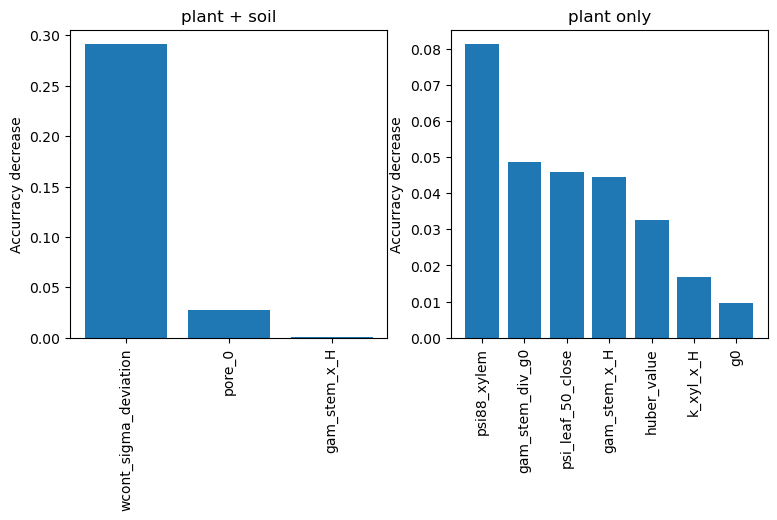

In [14]:
var_labs_size = [3,7]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(9, 4))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])
    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
    ax.tick_params(axis='x', labelrotation=90)
    
plt.show()

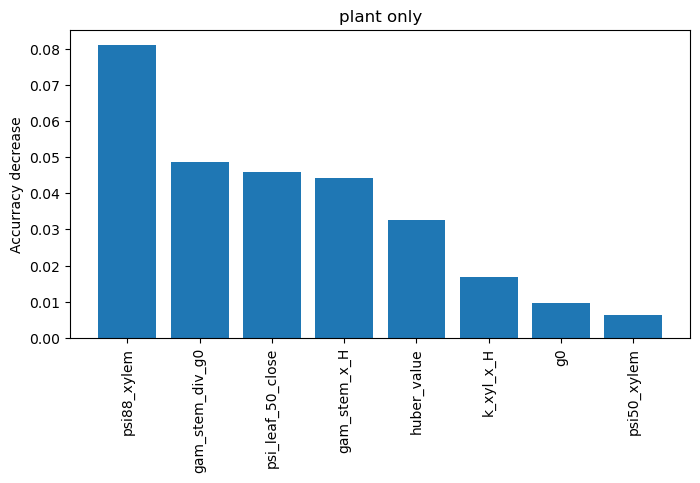

In [12]:
var_labs_size = [3,8]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 4))
for i in [1]:
    ax = fig.add_subplot(1, 1, 1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])
    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
    ax.tick_params(axis='x', labelrotation=90)
    
plt.show()

In [13]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{close}$"
label_dict['k_soil_sat0'] = r"$K_\mathrm{soil, sat}$"
label_dict['psi_soil_sat0'] = r"$\psi_\mathrm{soil, sat}$"
label_dict['d_50_close'] = r"$d_\mathrm{close}$"

In [36]:
labs = imps[0][0:var_labs_size[i]].index.tolist()

IndexError: list index out of range

In [37]:
labs_tex = [label_dict[lab] for lab in labs]

NameError: name 'label_dict' is not defined

In [10]:
labs_tex

['$\\sigma_\\mathrm{wcont}$',
 '$\\xi$',
 '$\\Gamma_\\mathrm{Stem}$',
 '$\\psi_{88}$',
 'Huber']

In [11]:
#labs_all =[r"$\sigma_\mathrm{wcont}$", r"Root $\beta$",r"$g_1$"]

#labs_plant =[ r"Huber", r"$g_0$",r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl, sat}$", r"$\psi_{50}$",r"$\Gamma_\mathrm{Leaf}$"]

In [35]:
plt.rcParams["font.family"] = "Avenir"
var_labs_size = [3,7]
title_labs  = ["plant + soil", "plant only"]
fig = plt.figure(figsize=(8, 3.5))
for i in range(0, len(imps)):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps[i][0:var_labs_size[i]].index,imps[i][0:var_labs_size[i]]['importance_mean'])

    labs = imps[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    
    ax.set_xticklabels(labs_tex)
    

    ax.set_title(title_labs[i])
    ax.set_ylabel("Accurracy decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F2_RF_classifier.png"), bbox_inches='tight', dpi=300)
plt.show()


<Figure size 800x350 with 0 Axes>

In [46]:
imps_regress = []
from sklearn import metrics

for i in range(0, 2):
    if i == 0:
        dfs_norm = df_norm[df_norm['sid'] == 0]
    else:
        dfs_norm = df_norm[df_norm['sid'] > 0]
        
    X_train, X_test, y_train, y_test = train_test_split(dfs_norm[vars_all], dfs_norm['RMSE_MAX'], test_size=0.3, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15, 
        random_state=2909)
    
    rf.fit(X_train, y_train)
    
    print(rf.score(X_train, y_train))
    
    print('Root Mean Squared Error (RMSE) train:', metrics.root_mean_squared_error(y_train, rf.predict(X_train)))
    print('Root Mean Squared Error (RMSE) test:', metrics.root_mean_squared_error(y_test, rf.predict(X_test)))   


    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="neg_root_mean_squared_error",  # we can use any metric
        n_repeats=50,
        random_state=42
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps_regress.append(importance)

0.9446077683364338
Root Mean Squared Error (RMSE) train: 0.02589096103602453
Root Mean Squared Error (RMSE) test: 0.05512957786495901
0.8731726824876908
Root Mean Squared Error (RMSE) train: 0.03896426995198147
Root Mean Squared Error (RMSE) test: 0.06373714920100175


In [17]:
imps_regress[0]

,importance_mean,importance_std
psi_leaf_50_close,0.045298,0.000567
k_xylem_sat,0.024610,0.000515
huber_value,0.006123,0.000274
stem_hydraulic_capacitance,0.004103,0.000205
g0,0.002990,0.000168
psi_soil_sat0,0.000686,0.000065
k_soil_sat0,0.000423,0.000068
g_stem_res,0.000241,0.000064
wcont_sigma_deviation,0.000068,0.000048
pore_0,0.000068,0.000036


In [19]:
imps_regress[1]

,importance_mean,importance_std
psi_leaf_50_close,0.032147,0.000284
k_xylem_sat,0.023004,0.000289
psi88_xylem,0.003322,0.000134
stem_hydraulic_capacitance,0.003261,0.000109
wcont_sigma_deviation,0.002910,0.000095
huber_value,0.002386,0.000061
g0,0.001433,0.000059
psi50_xylem,0.000766,0.000055
pore_0,0.000685,0.000055
g_stem_res,0.000333,0.000032


In [52]:
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, sat}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_\mathrm{close}$"
label_dict['d_50_close'] = r"$d_{close}$"
label_dict['g_stem_res'] = r"$g_\mathrm{Stem,res}$"
label_dict['psi_soil_sat0'] =r"$\psi_\mathrm{soil, sat}$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{\Gamma_\mathrm{Stem}}{g_0}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"


NameError: name 'label_dict' is not defined

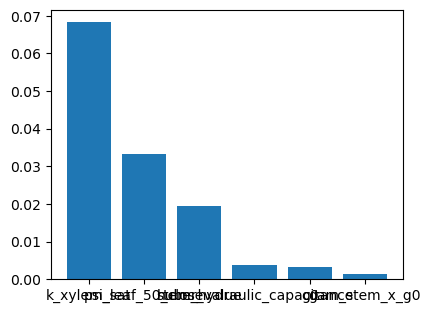

In [31]:
var_labs_size = [6, 7]

title_labs  = ["surviving", "dying"]
fig = plt.figure(figsize=(10, 3.5))
for i in range(0, 2):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps_regress[i][0:var_labs_size[i]].index,imps_regress[i][0:var_labs_size[i]]['importance_mean'])
    labs = imps_regress[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    
    ax.set_xticklabels(labs_tex)
    ax.set_title(title_labs[i])
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel("RMSE decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F3_RF_regressor.png"), bbox_inches='tight', dpi=300)
plt.show()

In [47]:
imps_regress = []
from sklearn import metrics

for i in range(0, 2):
    if i == 0:
        dfs_norm = df_norm[df_norm['sid'] == 0]
    else:
        dfs_norm = df_norm[df_norm['sid'] > 0]
        
    X_train, X_test, y_train, y_test = train_test_split(dfs_norm[vars_plant_ex], dfs_norm['RMSE_MAX'], test_size=0.3, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15, 
        random_state=2909)
    
    rf.fit(X_train, y_train)
    
    print(rf.score(X_train, y_train))
    
    print('Root Mean Squared Error (RMSE) train:', metrics.root_mean_squared_error(y_train, rf.predict(X_train)))
    print('Root Mean Squared Error (RMSE) test:', metrics.root_mean_squared_error(y_test, rf.predict(X_test)))   


    perm = permutation_importance(
        rf,
        X_test,  # we use the test set
        y_test,
        scoring="neg_root_mean_squared_error",  # we can use any metric
        n_repeats=50,
        random_state=42
    )
    importance = pd.DataFrame(
        {"importance_mean": perm["importances_mean"],
         "importance_std": perm["importances_std"]},
        index=rf.feature_names_in_)
    importance.sort_values(by="importance_mean",
                           ascending=False, inplace=True
                           )
    imps_regress.append(importance)

0.9414064503799848
Root Mean Squared Error (RMSE) train: 0.026628619017006555
Root Mean Squared Error (RMSE) test: 0.0555887410604463
0.8645309127620302
Root Mean Squared Error (RMSE) train: 0.04026987137294722
Root Mean Squared Error (RMSE) test: 0.06444439545461583


In [48]:
imps_regress[0]

,importance_mean,importance_std
k_xyl_x_H,0.059113,0.000884
psi_leaf_50_close,0.033270,0.000449
gam_stem_div_g0,0.003775,0.000241
g0,0.003389,0.000236
gam_stem_x_H,0.002869,0.000213
k_xylem_sat,0.001031,0.000122
g_min_loss,0.000458,0.000117
huber_value,0.000175,0.000088
stem_hydraulic_capacitance,0.000159,0.000065
leaf_hydraulic_capacitance,0.000087,0.000080


In [27]:
imps_regress[0][0:var_labs_size[i]].index.tolist()


['k_xylem_sat',
 'psi_leaf_50_close',
 'huber_value',
 'stem_hydraulic_capacitance',
 'g0',
 'gam_stem_x_g0',
 'gam_stem_div_H']

In [28]:
labs_tex

['k_xylem_sat',
 'psi_leaf_50_close',
 'huber_value',
 'stem_hydraulic_capacitance',
 'psi88_xylem',
 'g0',
 'psi50_xylem']

/tmp/ipykernel_1500527/1600752004.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
/tmp/ipykernel_1500527/1600752004.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labs_tex)
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

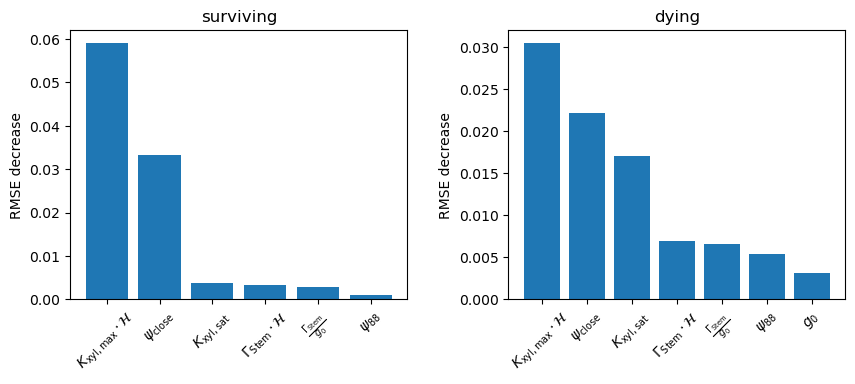

In [53]:
var_labs_size = [6, 7]

title_labs  = ["surviving", "dying"]
fig = plt.figure(figsize=(10, 3.5))
for i in range(0, 2):
    ax = fig.add_subplot(1, 2, i+1)
    ax.bar(imps_regress[i][0:var_labs_size[i]].index,imps_regress[i][0:var_labs_size[i]]['importance_mean'])# labs = imps_regress[i][0:var_labs_size[i]].index.tolist()
    
    labs_tex = [label_dict[lab] for lab in labs]
    ax.set_xticklabels(labs_tex)
    ax.set_title(title_labs[i])
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel("RMSE decrease")
plt.subplots_adjust(wspace=0.3)

plt.savefig(os.path.join(post_path, "F3_RF_regressor.png"), bbox_inches='tight', dpi=300)
plt.show()